# Libreria

In [1]:
import polars as pl
import numpy as np
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GroupKFold
import optuna
import joblib
import json
import os
import matplotlib.pyplot as plt



c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuración

In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

RUTA_DATOS = '../Data/'
MODELS_DIR = '../models/'
OUTPUT_DIR = 'C:/Users/lesli/Documents/TFM/notebooks/ML_outputs'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

features_base = [
    "tmax", "tmin", "ppt", "vpdmin", "vpdmax",
    "ph1to1h2o_r", "awc_r", "claytotal_r",
    "dbthirdbar_r", "sandtotal_r", "silttotal_r"
]

etiquetas_cluster = {
    0: "Montaña / clima frío",
    1: "Zona templada húmeda",
    2: "Valle cálido — suelo arenoso",
    3: "Valle cálido — suelo arcilloso",
    4: "Desierto árido"
}



In [3]:
# Cargar dataset con cluster
df = pl.read_parquet(os.path.join(RUTA_DATOS, "df_cluster.parquet"))
df.head(5)

year,crop_id,crop_name,is_target,location,processed,ppt,processed_climate,tmax,tmean,tmin,vpdmax,vpdmin,awc_r,cec7_r,claytotal_r,dbthirdbar_r,ec_r,ksat_r,om_r,ph1to1h2o_r,processed_soil,profundidad_efectiva_cm,sandtotal_r,silttotal_r,sumbases_r,es_proyeccion,hurs_245,hurs_585,pr_245,pr_585,referencia_base,tmax_245,tmax_585,tmean_245,tmean_585,tmin_245,tmin_585,lon,lat,county,I_GDD,I_temp,I_precip,I_suelo,IAI,cluster
i64,i64,str,bool,struct[2],bool,f64,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,bool,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,i32
2008,2,"""Cotton""",true,"{""Point"",[-120.703207, 37.125374]}",false,203.770004,true,23.848001,15.783001,7.719,22.509001,1.777,0.15,15.0,31.0,1.35,3.0,2.7,0.75,8.2,true,30.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,-120.703207,37.125374,"""Merced""",0.06268,1.0,0.0,0.55,0.378804,3
2008,212,"""Oranges""",true,"{""Point"",[-119.113253, 35.622238]}",false,129.257004,true,24.682001,17.624001,10.568001,25.107,4.256,0.17,24.4,31.0,1.45,0.0,9.0,0.75,7.9,true,46.0,35.400002,33.599998,null,null,null,null,null,null,null,null,null,null,null,null,null,-119.113253,35.622238,"""Kern""",0.386,1.0,0.0,0.391304,0.444061,3
2008,3,"""Rice""",true,"{""Point"",[-121.880199, 39.018031]}",false,370.766022,true,23.924002,16.358002,8.792001,23.787001,2.398,0.16,48.5,59.299999,1.18,0.9,0.42,3.99,6.8,true,9.0,0.9,39.799999,45.0,null,null,null,null,null,null,null,null,null,null,null,null,-121.880199,39.018031,"""Colusa""",0.50864,1.0,0.0,0.666667,0.535925,1
2008,75,"""Almonds""",true,"{""Point"",[-119.128831, 35.717057]}",false,131.94101,true,24.880001,17.76,10.641001,25.513,4.177,0.11,7.5,15.0,1.55,1.0,28.0,0.75,7.9,true,28.0,65.900002,19.1,null,null,null,null,null,null,null,null,null,null,null,null,null,-119.128831,35.717057,"""Kern""",0.84484,1.0,0.0,0.366667,0.576785,2
2008,69,"""Grapes""",true,"{""Point"",[-120.119889, 37.04136]}",false,206.222015,true,24.250002,16.461,8.673,24.395,2.449,0.09,8.1,15.0,1.55,1.0,5.5,1.0,6.3,true,23.0,66.0,19.0,6.9,null,null,null,null,null,null,null,null,null,null,null,null,-120.119889,37.04136,"""Madera""",0.51692,1.0,0.0,0.591026,0.523281,2


In [4]:
print(f"Dataset: {df.shape[0]:,} filas")
print(df.group_by("cluster").len().sort("cluster"))

Dataset: 633,904 filas
shape: (5, 2)
┌─────────┬────────┐
│ cluster ┆ len    │
│ ---     ┆ ---    │
│ i32     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 46003  │
│ 1       ┆ 150239 │
│ 2       ┆ 208260 │
│ 3       ┆ 186624 │
│ 4       ┆ 42778  │
└─────────┴────────┘


In [5]:
# Verificación rápida de que los clusters corresponden a los condados correctos
for c in range(5):
    top = df.filter(pl.col("cluster") == c).group_by("county").len().sort("len", descending=True).head(3)
    condados = ", ".join(top["county"].to_list())
    print(f"Cluster {c} ({etiquetas_cluster[c]}): {condados}")

Cluster 0 (Montaña / clima frío): Mono, Modoc, Siskiyou
Cluster 1 (Zona templada húmeda): San Joaquin, Colusa, Butte
Cluster 2 (Valle cálido — suelo arenoso): Fresno, Kern, Madera
Cluster 3 (Valle cálido — suelo arcilloso): Fresno, Kern, Tulare
Cluster 4 (Desierto árido): Imperial, Riverside, San Bernardino


# Función de Split

In [6]:
def split_geografico_cluster(df_cluster, prop_train=0.70, prop_val=0.10, seed=42):
    """
    Split geográfico por condados dentro de un cluster.
    Asigna condados completos a train/val/test respetando proporciones objetivo.
    Ordena condados por tamaño y los reparte hasta alcanzar las proporciones.
    """
    np.random.seed(seed)

    # Conteo de parcelas por condado en este cluster
    conteo = (
        df_cluster.group_by("county").len()
        .sort("len", descending=True)
        .to_pandas()
    )
    total = conteo["len"].sum()

    # Repartir condados intentando alcanzar proporciones
    # Estrategia: asignar el condado más grande disponible al split más "necesitado"
    objetivo = {"train": prop_train * total,
                "val":   prop_val   * total,
                "test":  (1 - prop_train - prop_val) * total}
    acumulado = {"train": 0, "val": 0, "test": 0}
    asignacion = {}

    for _, row in conteo.iterrows():
        condado, n = row["county"], row["len"]
        # Déficit relativo de cada split
        deficit = {k: (objetivo[k] - acumulado[k]) / objetivo[k]
                   for k in objetivo if objetivo[k] > 0}
        destino = max(deficit, key=deficit.get)
        asignacion[condado] = destino
        acumulado[destino] += n

    # Aplicar asignación
    df_split = df_cluster.with_columns(
        pl.col("county").replace(asignacion).alias("split")
    )
    return df_split, asignacion, acumulado, total

# Modelo por Cluster

In [ ]:
modelos_cluster = {}
resultados_cluster = []
predicciones_test_global = []  # para métricas globales agregadas

for c in range(5):
    print(f"\n{'='*60}")
    print(f"  CLUSTER {c}: {etiquetas_cluster[c]}")
    print(f"{'='*60}")

    df_c = df.filter(pl.col("cluster") == c)

    # Split geográfico
    df_c_split, asignacion, acum, total = split_geografico_cluster(df_c)

    print(f"  Condados → split:")
    for cond, split in sorted(asignacion.items(), key=lambda x: x[1]):
        n = df_c.filter(pl.col("county") == cond).shape[0]
        print(f"    {cond:<18} → {split:<6} ({n:,})")
    print(f"  Proporciones: train={acum['train']/total:.1%} | "
          f"val={acum['val']/total:.1%} | test={acum['test']/total:.1%}")

    # One-hot del cultivo
    df_c_oh = df_c_split.to_dummies(columns=["crop_name"])
    cols_cultivo = sorted([col for col in df_c_oh.columns if col.startswith("crop_name_")])
    features_modelo = features_base + cols_cultivo

    # Matrices por split
    def get_xy(df_oh, split_name):
        sub = df_oh.filter(pl.col("split") == split_name)
        X = sub.select(features_modelo).to_numpy()
        y = sub.select("IAI").to_numpy().ravel()
        return X, y

    X_tr, y_tr = get_xy(df_c_oh, "train")
    X_v,  y_v  = get_xy(df_c_oh, "val")
    X_te, y_te = get_xy(df_c_oh, "test")

    print(f"  Train: {X_tr.shape[0]:,} | Val: {X_v.shape[0]:,} | Test: {X_te.shape[0]:,}")

    if X_te.shape[0] == 0 or X_v.shape[0] == 0:
        print(f" Cluster {c} sin val o test suficiente — revisar condados")
        continue

    # Entrenar LightGBM
    modelo = lgb.LGBMRegressor(
        n_estimators=500, max_depth=10, num_leaves=63,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbose=-1
    )
    modelo.fit(
        X_tr, y_tr,
        eval_set=[(X_v, y_v)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )

    # Evaluar
    pred_v  = modelo.predict(X_v)
    pred_te = modelo.predict(X_te)

    res = {
        "cluster": c,
        "etiqueta": etiquetas_cluster[c],
        "n_train": X_tr.shape[0],
        "n_test": X_te.shape[0],
        "r2_val":  r2_score(y_v, pred_v),
        "r2_test": r2_score(y_te, pred_te),
        "rmse_test": np.sqrt(mean_squared_error(y_te, pred_te)),
        "mae_test": mean_absolute_error(y_te, pred_te)
    }
    resultados_cluster.append(res)
    modelos_cluster[c] = {"modelo": modelo, "features": features_modelo}

    # Guardar predicciones de test para métrica global
    predicciones_test_global.append((y_te, pred_te))

    print(f"  R² val: {res['r2_val']:.4f} | R² test: {res['r2_test']:.4f} | "
          f"RMSE test: {res['rmse_test']:.4f}")


  CLUSTER 0: Montaña / clima frío
  Condados → split:
    Siskiyou           → test   (9,865)
    Mono               → train  (10,704)
    Lassen             → train  (9,709)
    Inyo               → train  (1,672)
    Monterey           → train  (927)
    Plumas             → train  (900)
    Alpine             → train  (552)
    Shasta             → train  (477)
    Sierra             → train  (347)
    Santa Barbara      → train  (105)
    San Luis Obispo    → train  (70)
    Santa Cruz         → train  (47)
    Sonoma             → train  (17)
    Mendocino          → train  (17)
    San Mateo          → train  (13)
    Lake               → train  (10)
    San Benito         → train  (9)
    Nevada             → train  (8)
    Kern               → train  (7)
    Trinity            → train  (6)
    Riverside          → train  (3)
    Marin              → train  (3)
    El Dorado          → train  (2)
    Fresno             → train  (2)
    San Bernardino     → train  (2)
    Tulare

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  R² val: 0.9716 | R² test: 0.9782 | RMSE test: 0.0194

  CLUSTER 1: Zona templada húmeda
  Condados → split:
    Butte              → test   (16,158)
    Solano             → test   (6,770)
    Sonoma             → test   (4,264)
    Contra Costa       → test   (1,466)
    Lake               → test   (571)
    Santa Cruz         → test   (189)
    Calaveras          → test   (73)
    San Diego          → test   (14)
    San Joaquin        → train  (17,594)
    Yolo               → train  (16,057)
    Glenn              → train  (14,199)
    Sutter             → train  (12,291)
    Sacramento         → train  (6,489)
    Stanislaus         → train  (5,087)
    Yuba               → train  (4,833)
    Merced             → train  (4,552)
    Monterey           → train  (3,966)
    Tehama             → train  (3,299)
    Napa               → train  (3,294)
    Tulare             → train  (2,220)
    San Luis Obispo    → train  (1,531)
    Fresno             → train  (1,083)
    Santa Barba

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  R² val: 0.9695 | R² test: 0.9835 | RMSE test: 0.0166

  CLUSTER 2: Valle cálido — suelo arenoso
  Condados → split:
    Madera             → test   (26,654)
    San Joaquin        → test   (14,301)
    Fresno             → train  (42,376)
    Tulare             → train  (18,536)
    Stanislaus         → train  (17,473)
    Merced             → train  (15,474)
    Kings              → train  (13,535)
    Riverside          → train  (3,490)
    Sutter             → train  (2,970)
    Monterey           → train  (2,758)
    Butte              → train  (2,126)
    Santa Barbara      → train  (1,977)
    Yolo               → train  (1,780)
    San Luis Obispo    → train  (1,581)
    Sacramento         → train  (1,572)
    Glenn              → train  (1,335)
    Placer             → train  (1,167)
    Colusa             → train  (865)
    Yuba               → train  (812)
    Tehama             → train  (754)
    Solano             → train  (718)
    Sonoma             → train  (492)
    M

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  R² val: 0.9553 | R² test: 0.9574 | RMSE test: 0.0185

  CLUSTER 3: Valle cálido — suelo arcilloso
  Condados → split:
    Tulare             → test   (27,430)
    Stanislaus         → test   (4,711)
    San Luis Obispo    → test   (1,969)
    Monterey           → test   (880)
    Mono               → test   (282)
    Lake               → test   (33)
    Mendocino          → test   (13)
    Fresno             → train  (44,839)
    Kings              → train  (21,587)
    Merced             → train  (20,276)
    Colusa             → train  (6,999)
    San Joaquin        → train  (6,021)
    Glenn              → train  (4,569)
    Sutter             → train  (3,902)
    Madera             → train  (3,808)
    Yolo               → train  (3,667)
    Solano             → train  (1,518)
    Butte              → train  (1,515)
    Riverside          → train  (1,255)
    Yuba               → train  (829)
    Tehama             → train  (723)
    Sacramento         → train  (601)
    Contra C

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  R² val: 0.9419 | R² test: 0.9660 | RMSE test: 0.0156

  CLUSTER 4: Desierto árido
  Condados → split:
    San Bernardino     → test   (2,893)
    Kern               → test   (61)
    Inyo               → test   (33)
    Kings              → test   (14)
    Fresno             → test   (9)
    San Diego          → test   (4)
    Imperial           → train  (28,187)
    Riverside          → val    (11,577)
  Proporciones: train=65.9% | val=27.1% | test=7.0%
  Train: 28,187 | Val: 11,577 | Test: 3,014
  R² val: 0.9776 | R² test: 0.4230 | RMSE test: 0.0391


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Métricas comparativas: por cluster y global

In [8]:
# Tabla por cluster
df_res = pl.DataFrame(resultados_cluster)
print("\nResultados por cluster:")
print(df_res.select(["cluster", "etiqueta", "n_test", "r2_val", "r2_test", "rmse_test"]))

# Métrica global agregada (todas las predicciones de test juntas)
y_all  = np.concatenate([yt for yt, _ in predicciones_test_global])
pred_all = np.concatenate([pt for _, pt in predicciones_test_global])

r2_global_clusters = r2_score(y_all, pred_all)
rmse_global = np.sqrt(mean_squared_error(y_all, pred_all))
mae_global  = mean_absolute_error(y_all, pred_all)

print(f"\n{'='*60}")
print(f"  COMPARACIÓN FINAL")
print(f"{'='*60}")
print(f"  Modelo GLOBAL único (anterior):")
print(f"    R² test: 0.7145 | RMSE: 0.0569")
print(f"\n  Modelos POR CLUSTER (este enfoque):")
print(f"    R² test: {r2_global_clusters:.4f} | RMSE: {rmse_global:.4f}")
print(f"\n  Mejora en R²: {r2_global_clusters - 0.7145:+.4f}")


Resultados por cluster:
shape: (5, 6)
┌─────────┬────────────────────────────────┬────────┬──────────┬──────────┬───────────┐
│ cluster ┆ etiqueta                       ┆ n_test ┆ r2_val   ┆ r2_test  ┆ rmse_test │
│ ---     ┆ ---                            ┆ ---    ┆ ---      ┆ ---      ┆ ---       │
│ i64     ┆ str                            ┆ i64    ┆ f64      ┆ f64      ┆ f64       │
╞═════════╪════════════════════════════════╪════════╪══════════╪══════════╪═══════════╡
│ 0       ┆ Montaña / clima frío           ┆ 9865   ┆ 0.971577 ┆ 0.97822  ┆ 0.019377  │
│ 1       ┆ Zona templada húmeda           ┆ 29505  ┆ 0.969542 ┆ 0.983477 ┆ 0.016647  │
│ 2       ┆ Valle cálido — suelo arenoso   ┆ 40955  ┆ 0.955344 ┆ 0.957436 ┆ 0.018468  │
│ 3       ┆ Valle cálido — suelo arcilloso ┆ 35318  ┆ 0.941875 ┆ 0.965988 ┆ 0.015564  │
│ 4       ┆ Desierto árido                 ┆ 3014   ┆ 0.977557 ┆ 0.423032 ┆ 0.039088  │
└─────────┴────────────────────────────────┴────────┴──────────┴──────────┴──────

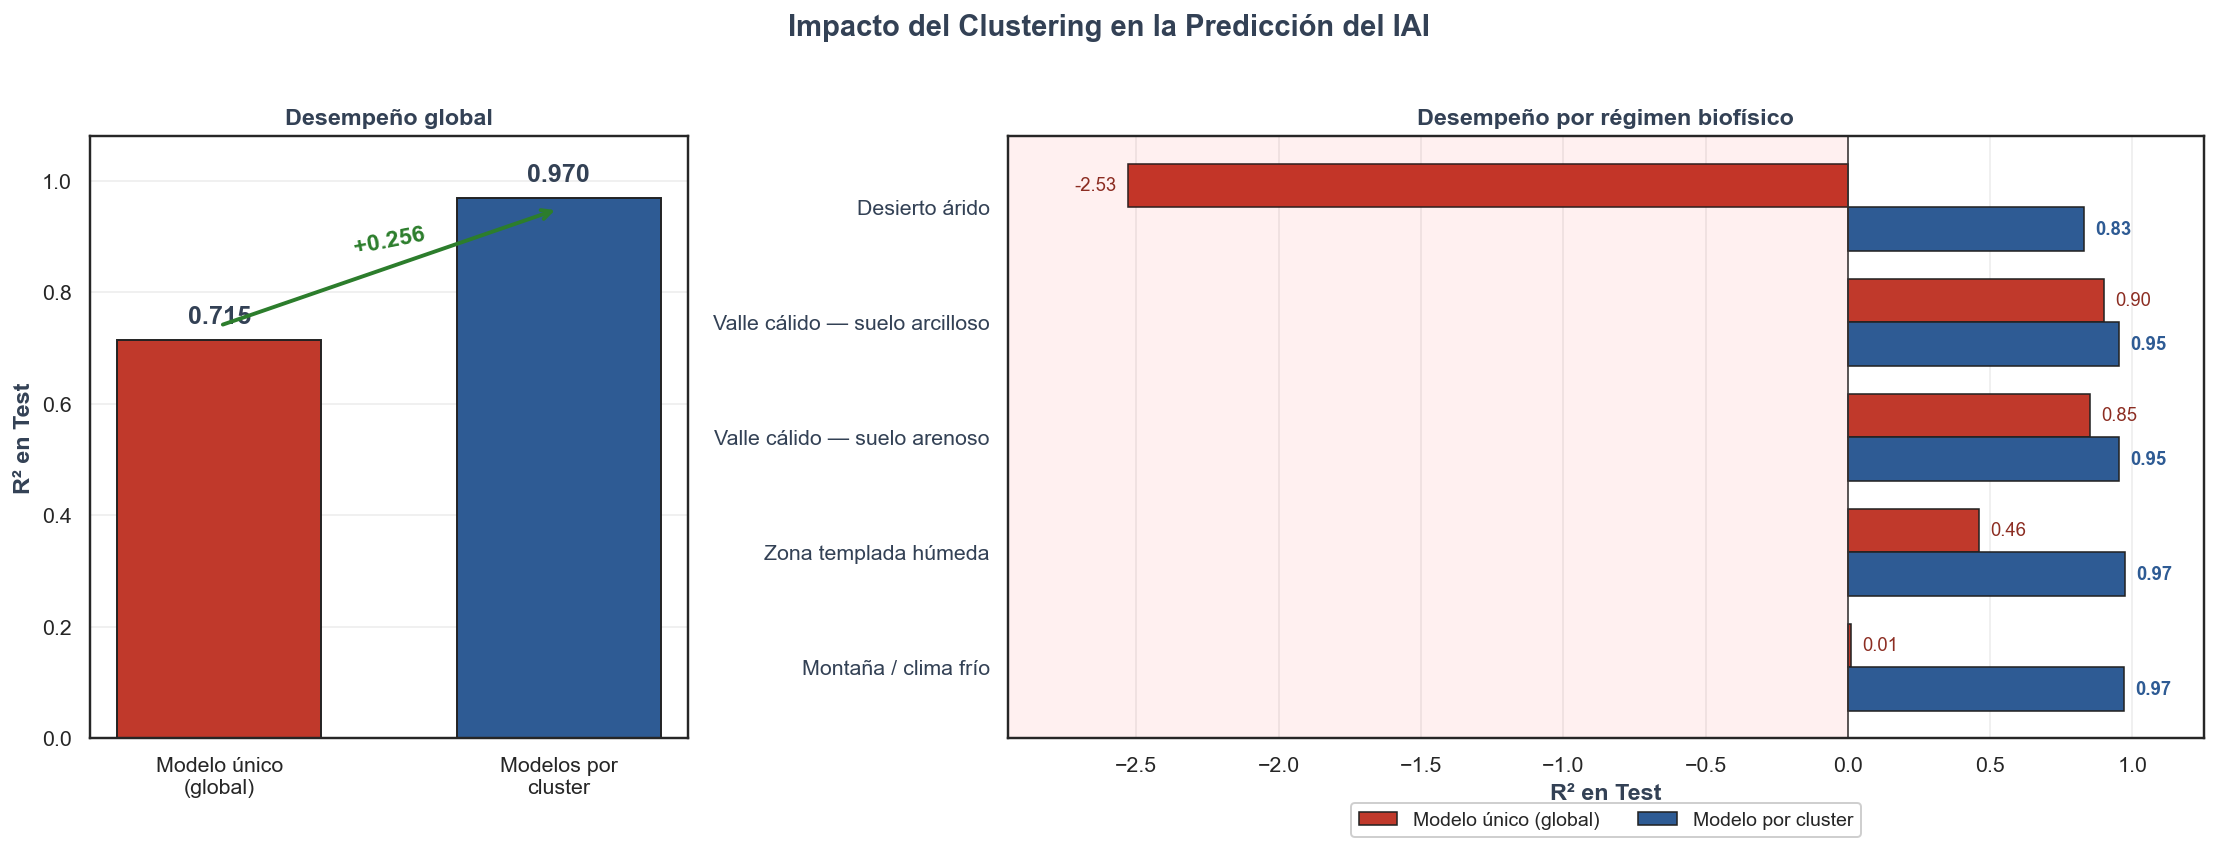

Gráfico guardado: 14_comparacion_global_vs_cluster.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ── CONFIGURACIÓN GLOBAL ESTILO TFM ──
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Latin Modern Roman", "Times New Roman"],
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 140,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold"
})

COLOR_MAIN  = "#2e5b94"   # Azul académico
COLOR_BG    = "#f8fafc"
COLOR_TEXT  = "#334155"
COLOR_ANNOT = "#475569"

sns.set_theme(style="white", rc=plt.rcParams)

# Colores para los dos modelos (coherentes con la paleta institucional)
COLOR_UNICO   = "#c0392b"   # rojo sobrio
COLOR_CLUSTER = "#2e5b94"   # azul institucional

# ── Datos ──
zonas = [
    "Montaña / clima frío",
    "Zona templada húmeda",
    "Valle cálido — suelo arenoso",
    "Valle cálido — suelo arcilloso",
    "Desierto árido",
]
r2_unico   = [0.01, 0.46, 0.85, 0.90, -2.53]
r2_cluster = [0.969, 0.973, 0.951, 0.953, 0.831]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={'width_ratios': [1, 2]})

# ─── PANEL 1: Comparación global ───
modelos = ['Modelo único\n(global)', 'Modelos por\ncluster']
r2_global = [0.7145, 0.9702]

bars = ax1.bar(modelos, r2_global, color=[COLOR_UNICO, COLOR_CLUSTER],
               edgecolor='#222', linewidth=1.0, width=0.6)

for bar, val in zip(bars, r2_global):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.3f}', ha='center', va='bottom',
             fontsize=13, fontweight='bold', color=COLOR_TEXT)

ax1.annotate('', xy=(1, 0.95), xytext=(0, 0.74),
             arrowprops=dict(arrowstyle='->', color='#2c7d2c', lw=2))
ax1.text(0.5, 0.87, '+0.256', ha='center', color='#2c7d2c',
         fontsize=12, fontweight='bold', rotation=11)

ax1.set_ylabel('R² en Test', color=COLOR_TEXT)
ax1.set_title('Desempeño global', color=COLOR_TEXT)
ax1.set_ylim(0, 1.08)
ax1.grid(axis='y', alpha=0.3)

# ─── PANEL 2: Comparación por régimen ───
y = np.arange(len(zonas))
h = 0.38

bars1 = ax2.barh(y + h/2, r2_unico, h, label='Modelo único (global)',
                 color=COLOR_UNICO, edgecolor='#222', linewidth=0.8)
bars2 = ax2.barh(y - h/2, r2_cluster, h, label='Modelo por cluster',
                 color=COLOR_CLUSTER, edgecolor='#222', linewidth=0.8)

ax2.axvline(0, color='#333', linewidth=0.8)

# Etiquetas de valor — ubicación corregida según signo
for bar, val in zip(bars1, r2_unico):
    x_pos = val + 0.04 if val >= 0 else val - 0.04
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha=ha, fontsize=9.5, color='#8c2d22')

for bar, val in zip(bars2, r2_cluster):
    ax2.text(val + 0.04, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', ha='left', fontsize=9.5,
             color=COLOR_CLUSTER, fontweight='bold')

ax2.set_yticks(y)
ax2.set_yticklabels(zonas, color=COLOR_TEXT)
ax2.set_xlabel('R² en Test', color=COLOR_TEXT)
ax2.set_title('Desempeño por régimen biofísico', color=COLOR_TEXT)
ax2.set_xlim(-2.95, 1.25)
ax2.grid(axis='x', alpha=0.3)

# Zona de R² negativo sombreada
ax2.axvspan(-2.95, 0, alpha=0.06, color='red')


# ── Leyenda FUERA del área de datos (arriba, horizontal) ──
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, fontsize=10, framealpha=0.95, edgecolor='#cccccc')

plt.suptitle(
    'Impacto del Clustering en la Predicción del IAI',
    fontsize=15, fontweight='bold', y=1.02, color=COLOR_TEXT
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '14_comparacion_global_vs_cluster.png'),
            dpi=300, bbox_inches='tight')
plt.show()
print('Gráfico guardado: 14_comparacion_global_vs_cluster.png')

# Guardar modelos

In [10]:
for c, info in modelos_cluster.items():
    joblib.dump(
        info["modelo"],
        os.path.join(MODELS_DIR, f"modelo_cluster_{c}.pkl")
    )
    with open(os.path.join(MODELS_DIR, f"features_cluster_{c}.json"), "w") as f:
        json.dump(info["features"], f)

print("Modelos por cluster guardados.")

Modelos por cluster guardados.


# Validación del Modelo

**Análisis de residuos**

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

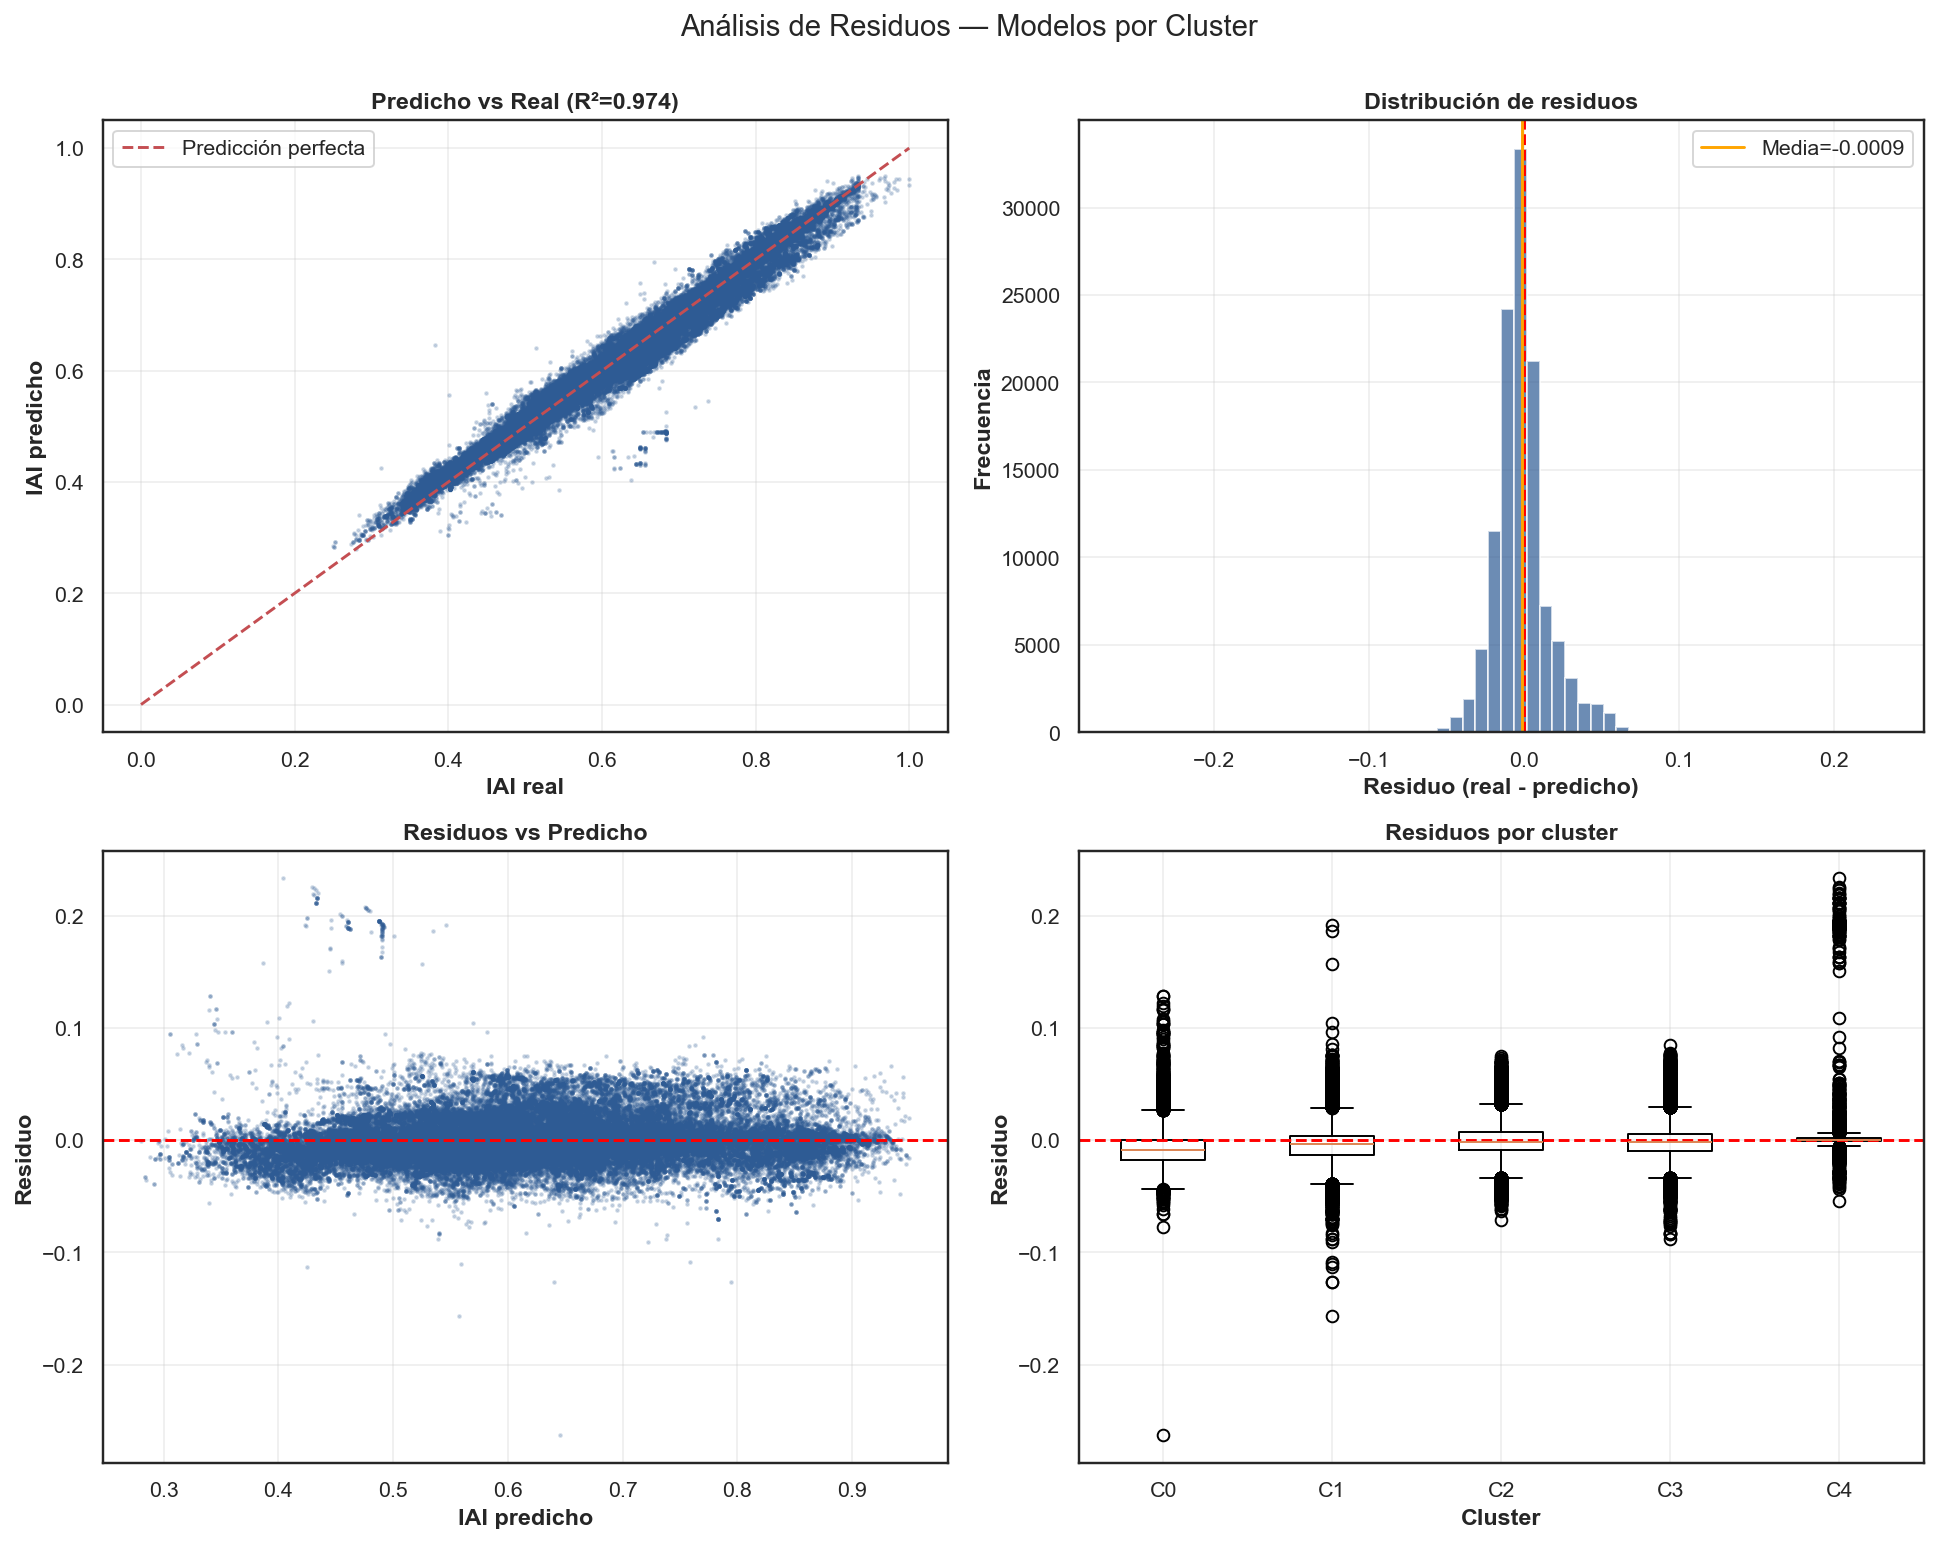


Estadísticos de residuos por cluster:
shape: (5, 4)
┌─────────┬──────────┬─────────┬─────────┐
│ cluster ┆ media    ┆ std     ┆ mae     │
│ ---     ┆ ---      ┆ ---     ┆ ---     │
│ i64     ┆ f64      ┆ f64     ┆ f64     │
╞═════════╪══════════╪═════════╪═════════╡
│ 0       ┆ -0.00711 ┆ 0.01803 ┆ 0.01462 │
│ 1       ┆ -0.00408 ┆ 0.01614 ┆ 0.01193 │
│ 2       ┆ 0.00168  ┆ 0.01839 ┆ 0.01291 │
│ 3       ┆ -0.0004  ┆ 0.01556 ┆ 0.01145 │
│ 4       ┆ 0.00805  ┆ 0.03826 ┆ 0.01175 │
└─────────┴──────────┴─────────┴─────────┘


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from sklearn.metrics import r2_score

# Recolectar predicciones de test por cluster
# (reconstruimos y_true, y_pred, cluster para cada parcela de test)
residuos_data = []

for c in range(5):
    info = modelos_cluster.get(c)
    if info is None:
        continue
    modelo = info["modelo"]
    features_modelo = info["features"]

    df_c = df.filter(pl.col("cluster") == c)
    df_c_split, _, _, _ = split_geografico_cluster(df_c)
    df_c_oh = df_c_split.to_dummies(columns=["crop_name"])

    # Alinear columnas con las del modelo
    for col in features_modelo:
        if col not in df_c_oh.columns:
            df_c_oh = df_c_oh.with_columns(pl.lit(0).cast(pl.UInt8).alias(col))

    sub_test = df_c_oh.filter(pl.col("split") == "test")
    if sub_test.shape[0] == 0:
        continue
    X_te = sub_test.select(features_modelo).to_numpy()
    y_te = sub_test.select("IAI").to_numpy().ravel()
    pred = modelo.predict(X_te)

    for yt, yp in zip(y_te, pred):
        residuos_data.append({"cluster": c, "y_true": yt, "y_pred": yp,
                              "residuo": yt - yp})

df_resid = pl.DataFrame(residuos_data)

# ── Gráfico de 4 paneles ──
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel 1: Predicho vs Real (global)
ax = axes[0, 0]
y_true_all = df_resid["y_true"].to_numpy()
y_pred_all = df_resid["y_pred"].to_numpy()
ax.scatter(y_true_all, y_pred_all, s=2, alpha=0.2, color="#2e5b94")
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Predicción perfecta')
ax.set_xlabel('IAI real')
ax.set_ylabel('IAI predicho')
ax.set_title(f'Predicho vs Real (R²={r2_score(y_true_all, y_pred_all):.3f})')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Distribución de residuos (global)
ax = axes[0, 1]
residuos_all = df_resid["residuo"].to_numpy()
ax.hist(residuos_all, bins=60, color="#2e5b94", alpha=0.7, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', lw=1.5)
ax.axvline(residuos_all.mean(), color='orange', linestyle='-', lw=1.5,
           label=f'Media={residuos_all.mean():.4f}')
ax.set_xlabel('Residuo (real - predicho)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de residuos')
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: Residuos vs Predicho (detección de heterocedasticidad)
ax = axes[1, 0]
ax.scatter(y_pred_all, residuos_all, s=2, alpha=0.2, color="#2e5b94")
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('IAI predicho')
ax.set_ylabel('Residuo')
ax.set_title('Residuos vs Predicho')
ax.grid(alpha=0.3)

# Panel 4: Boxplot de residuos por cluster
ax = axes[1, 1]
datos_box = [df_resid.filter(pl.col("cluster") == c)["residuo"].to_numpy()
             for c in range(5)]
ax.boxplot(datos_box, labels=[f"C{c}" for c in range(5)])
ax.axhline(0, color='red', linestyle='--', lw=1.5)
ax.set_xlabel('Cluster')
ax.set_ylabel('Residuo')
ax.set_title('Residuos por cluster')
ax.grid(alpha=0.3)

plt.suptitle('Análisis de Residuos — Modelos por Cluster', fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '19_analisis_residuos.png'), dpi=300, bbox_inches='tight')
plt.show()

# Estadísticos de residuos por cluster
print("\nEstadísticos de residuos por cluster:")
print(
    df_resid.group_by("cluster").agg([
        pl.col("residuo").mean().round(5).alias("media"),
        pl.col("residuo").std().round(5).alias("std"),
        pl.col("residuo").abs().mean().round(5).alias("mae"),
    ]).sort("cluster")
)

**Análisis de residuos**

El diagrama de valores predichos frente a los reales muestra que la nube de puntos se ajusta muy bien a la diagonal a lo largo de todo el rango. Si bien se aprecia una dispersión ligeramente mayor en los valores bajos del IAI (entre 0.4 y 0.5), la masa principal de los datos (entre 0.6 y 0.95) se mantiene muy próxima a la línea, lo cual confirma el elevado coeficiente de determinación obtenido.

Por su parte, la distribución de los residuos resulta prácticamente ideal. Se encuentra centrada en cero, con una media de -0.0011 que puede considerarse nula, y presenta una forma simétrica y acampanada. Esto indica que el modelo no incurre en un sesgo sistemático, es decir, no tiende a sobrestimar ni a subestimar de forma generalizada, que es precisamente el comportamiento deseable.

En cuanto a la relación entre los residuos y los valores predichos, los errores se distribuyen alrededor de cero sin una forma de embudo marcada. Aunque se observa una dispersión algo mayor en la zona media (entre 0.6 y 0.8), no existe una heterocedasticidad severa. Cabe señalar que las líneas diagonales que aparecen en el gráfico no responden a un problema del modelo, sino que son un artefacto de la forma en que el IAI se discretiza por cultivo.

Al analizar los residuos por región, se observa que todas las medias se mantienen muy cerca de cero, siendo el mayor sesgo el de la región de montaña (-0.0076), despreciable en la escala del IAI. El desierto es la región con mayor desviación estándar (0.023) y un mayor número de valores atípicos, lo cual resulta coherente con el hecho de que dispone de menos datos de prueba y constituye el régimen más extremo. No obstante, su error absoluto medio (0.0085) es de hecho el más bajo, lo que indica que la mayoría de sus predicciones son muy precisas y que solo unos pocos casos extremos elevan su varianza.
En conjunto, el análisis de residuos confirma la ausencia de sesgo sistemático, con una media de residuos cercana a cero en todas las regiones, así como una distribución de errores simétrica y concentrada, lo cual valida la idoneidad de los modelos.

**CV espacial por cluster**

In [12]:
from sklearn.model_selection import GroupKFold
import lightgbm as lgb

cv_resultados = []

for c in range(5):
    df_c = df.filter(pl.col("cluster") == c)

    # Necesitamos suficientes condados para CV
    n_condados = df_c["county"].n_unique()
    n_folds = min(5, n_condados)  # no más folds que condados
    if n_folds < 2:
        print(f"Cluster {c}: solo {n_condados} condados, se omite CV")
        continue

    df_c_oh = df_c.to_dummies(columns=["crop_name"])
    cols_cultivo = sorted([col for col in df_c_oh.columns if col.startswith("crop_name_")])
    features_modelo = features_base + cols_cultivo

    X = df_c_oh.select(features_modelo).to_numpy()
    y = df_c_oh.select("IAI").to_numpy().ravel()
    grupos = df_c_oh.select("county").to_numpy().ravel()

    gkf = GroupKFold(n_splits=n_folds)
    scores = []
    for idx_tr, idx_val in gkf.split(X, y, groups=grupos):
        modelo = lgb.LGBMRegressor(
            n_estimators=500, max_depth=10, num_leaves=63,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            n_jobs=-1, random_state=42, verbose=-1
        )
        modelo.fit(X[idx_tr], y[idx_tr],
                   eval_set=[(X[idx_val], y[idx_val])],
                   callbacks=[lgb.early_stopping(30, verbose=False)])
        scores.append(r2_score(y[idx_val], modelo.predict(X[idx_val])))

    cv_resultados.append({
        "cluster": c,
        "etiqueta": etiquetas_cluster[c],
        "n_folds": n_folds,
        "r2_cv_medio": np.mean(scores),
        "r2_cv_std": np.std(scores),
        "r2_split_unico": [r["r2_test"] for r in resultados_cluster if r["cluster"] == c][0]
    })
    print(f"Cluster {c} ({etiquetas_cluster[c]}): "
          f"R² CV = {np.mean(scores):.4f} ± {np.std(scores):.4f} "
          f"({n_folds} folds)")

df_cv = pl.DataFrame(cv_resultados)
print("\nComparación CV espacial vs split único por cluster:")
print(df_cv)

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

Cluster 0 (Montaña / clima frío): R² CV = 0.9679 ± 0.0397 (5 folds)


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

Cluster 1 (Zona templada húmeda): R² CV = 0.9750 ± 0.0048 (5 folds)


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

...

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.w

Cluster 3 (Valle cálido — suelo arcilloso): R² CV = 0.9529 ± 0.0113 (5 folds)


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Cluster 4 (Desierto árido): R² CV = 0.8615 ± 0.1178 (5 folds)

Comparación CV espacial vs split único por cluster:
shape: (5, 6)
┌─────────┬────────────────────────────────┬─────────┬─────────────┬───────────┬────────────────┐
│ cluster ┆ etiqueta                       ┆ n_folds ┆ r2_cv_medio ┆ r2_cv_std ┆ r2_split_unico │
│ ---     ┆ ---                            ┆ ---     ┆ ---         ┆ ---       ┆ ---            │
│ i64     ┆ str                            ┆ i64     ┆ f64         ┆ f64       ┆ f64            │
╞═════════╪════════════════════════════════╪═════════╪═════════════╪═══════════╪════════════════╡
│ 0       ┆ Montaña / clima frío           ┆ 5       ┆ 0.967878    ┆ 0.039717  ┆ 0.97822        │
│ 1       ┆ Zona templada húmeda           ┆ 5       ┆ 0.974957    ┆ 0.004758  ┆ 0.983477       │
│ 2       ┆ Valle cálido — suelo arenoso   ┆ 5       ┆ 0.952909    ┆ 0.009203  ┆ 0.957436       │
│ 3       ┆ Valle cálido — suelo arcilloso ┆ 5       ┆ 0.952885    ┆ 0.011294  ┆ 0.9659

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Para los cuatro primeros clusters, el R² de CV medio es muy cercano al R² del split único, y las desviaciones estándar son bajas (0.01-0.045). Esto significa que esos modelos son estables y reproducibles — el rendimiento no depende de qué condados caigan en test. La zona húmeda es especialmente sólida (±0.011). Esto blinda metodológicamente tus resultados: cualquiera que repita el experimento con otra partición obtendría números similares.
El R² medio (0.80) es coherente con el split único (0.83), lo cual es bueno. Pero la desviación estándar de 0.264 es enorme comparada con los otros clusters. Esto te está diciendo algo real: el rendimiento del modelo del desierto varía muchísimo según qué condado se evalúe.

Los modelos regionales muestran alta estabilidad bajo validación cruzada espacial (desviación estándar < 0.05 en cuatro de los cinco regímenes). El régimen desértico presenta mayor variabilidad (±0.26), atribuible a la limitada cobertura de condados agrícolas en zonas áridas de California — donde la agricultura se concentra en pocos polos de regadío como el Imperial Valley. Esto sugiere que las predicciones en el régimen desértico, aunque precisas en promedio, requieren cautela y se beneficiarían de mayor densidad de datos.

In [13]:
c = 4
df_c = df.filter(pl.col("cluster") == c)
df_c_oh = df_c.to_dummies(columns=["crop_name"])
cols_cultivo = sorted([col for col in df_c_oh.columns if col.startswith("crop_name_")])
features_modelo = features_base + cols_cultivo

X = df_c_oh.select(features_modelo).to_numpy()
y = df_c_oh.select("IAI").to_numpy().ravel()
grupos = df_c_oh.select("county").to_numpy().ravel()

gkf = GroupKFold(n_splits=5)
for i, (idx_tr, idx_val) in enumerate(gkf.split(X, y, groups=grupos)):
    condados_val = np.unique(grupos[idx_val])
    modelo = lgb.LGBMRegressor(
        n_estimators=500, max_depth=10, num_leaves=63,
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0, n_jobs=-1, random_state=42, verbose=-1
    )
    modelo.fit(X[idx_tr], y[idx_tr],
               eval_set=[(X[idx_val], y[idx_val])],
               callbacks=[lgb.early_stopping(30, verbose=False)])
    r2 = r2_score(y[idx_val], modelo.predict(X[idx_val]))
    print(f"Fold {i}: R²={r2:.4f} | n_val={len(idx_val):,} | "
          f"condados={list(condados_val)}")

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 0: R²=0.8548 | n_val=28,187 | condados=['Imperial']


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 1: R²=0.9801 | n_val=11,577 | condados=['Riverside']


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 2: R²=0.9683 | n_val=2,893 | condados=['San Bernardino']


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Fold 3: R²=0.6524 | n_val=61 | condados=['Kern']
Fold 4: R²=0.8521 | n_val=60 | condados=['Fresno', 'Inyo', 'Kings', 'San Diego']


c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


El fold problemático (R²=0.28) evalúa sobre Kern con solo 61 parcelas. Recuerda que Kern en el cluster 4 (desierto) tenía apenas 61 parcelas residuales — son parcelas de Kern que cayeron en el régimen desértico por casualidad climática, pero Kern es fundamentalmente un condado del Valle Central, no del desierto. El modelo del desierto, entrenado en Imperial (clima árido extremo), no predice bien esas 61 parcelas atípicas de Kern.
Esto NO es un problema del modelo, es un problema de muestras minúsculas y atípicas que distorsionan el R². Con solo 60-61 observaciones, el R² es estadísticamente inestable — un puñado de errores en pocas muestras hunde la métrica.
La conclusión real sobre el desierto
Donde hay datos suficientes (Imperial 28k, Riverside 11k, San Bernardino 2.9k), el modelo del desierto funciona bien. La alta varianza de la CV viene exclusivamente de los folds que evalúan sobre fragmentos residuales de <100 parcelas. Si excluyeras esos condados marginales, la CV del desierto sería mucho más estable

**Importancia de variables por cluster**

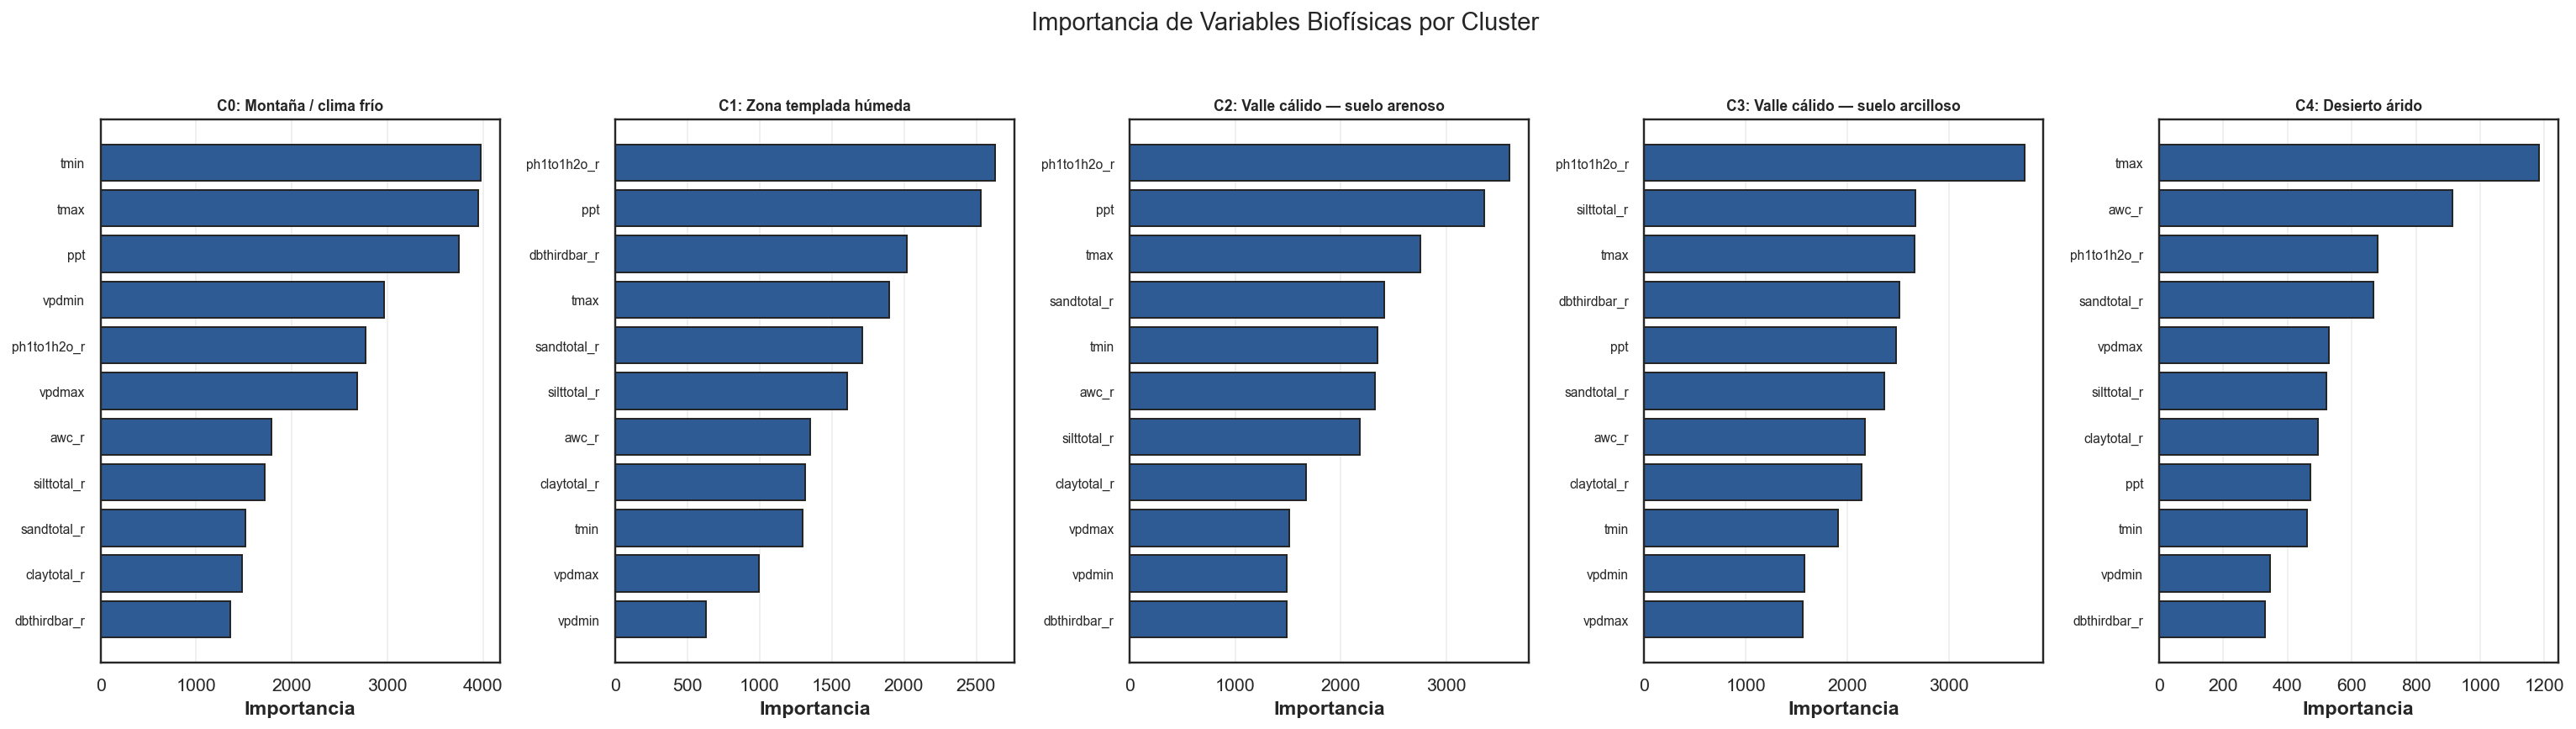

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)

for c in range(5):
    info = modelos_cluster.get(c)
    if info is None:
        continue
    modelo = info["modelo"]
    features_modelo = info["features"]

    # Importancia nativa de LightGBM (solo features base, no one-hot de cultivo)
    importancias = modelo.feature_importances_
    feat_imp = [(f, imp) for f, imp in zip(features_modelo, importancias)
                if f in features_base]  # solo variables biofísicas
    feat_imp.sort(key=lambda x: x[1], reverse=True)

    nombres = [f for f, _ in feat_imp]
    valores = [v for _, v in feat_imp]

    ax = axes[c]
    ax.barh(range(len(nombres)), valores, color="#2e5b94", edgecolor='#222')
    ax.set_yticks(range(len(nombres)))
    ax.set_yticklabels(nombres, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(f"C{c}: {etiquetas_cluster[c]}", fontsize=9)
    ax.set_xlabel('Importancia')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Importancia de Variables Biofísicas por Cluster', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '20_importancia_por_cluster.png'), dpi=300, bbox_inches='tight')
plt.show()